In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn import tree
import warnings

In [21]:
df_crop = pd.read_csv('../../dataset/dataset_yogyakarta_augmented.csv')

In [22]:
df_crop.head()

,temperature,humidity,rainfall,ph,nitrogen,phosphorous,potassium,carbon,soil,label
0,22.600000,73.200000,246.300000,6.470000,67.53,42.8400,76.0100,3.66,Loamy Soil,chives
1,31.300000,67.300000,107.800000,6.380000,23.90,63.3100,88.8700,1.62,Sandy Loam,peanut
2,29.572403,93.618703,27.569186,6.559763,54.24,93.8000,48.3500,1.14,Loamy Soil,muskmelon
3,16.188204,90.728507,108.583437,7.755478,56.81,59.7865,55.1455,1.21,Peaty Soil,orange
4,24.288889,83.036879,54.765762,6.653868,56.13,101.9700,61.1000,0.65,Neutral Soil,watermelon


In [23]:
df_crop.tail()

,temperature,humidity,rainfall,ph,nitrogen,phosphorous,potassium,carbon,soil,label
6286,25.965342,89.637252,58.993108,6.849472,57.6525,147.812772,92.6700,1.48,Loamy Soil,watermelon
6287,28.939399,81.439718,106.717373,6.664819,29.5400,37.890000,49.3100,2.23,Loamy Soil,mungbean
6288,24.073460,60.732411,110.870027,6.879552,33.0000,36.000000,32.0000,845.00,Loamy Soil,sweetpotato
6289,32.136814,78.930776,139.809395,6.561807,25.9500,34.440000,62.3100,1.97,Sandy Loam,mungbean
6290,22.504573,61.891003,245.878798,4.903373,69.0300,38.860000,55.4215,2.22,Acidic Soil,tea


In [24]:
df_crop.shape

(6291, 10)

In [25]:
df_crop.columns

Index(['temperature', 'humidity', 'rainfall', 'ph', 'nitrogen', 'phosphorous',
       'potassium', 'carbon', 'soil', 'label'],
      dtype='object')

In [26]:
df_crop['label'].unique()

array(['chives', 'peanut', 'muskmelon', 'orange', 'watermelon', 'coffee',
       'banana', 'garlic', 'cabbage', 'sweetpotato', 'tea', 'mango',
       'soybean', 'rice', 'papaya', 'shallots', 'maize', 'mungbean',
       'cassava', 'chilli'], dtype=object)

In [27]:
crop_mapping = {
    # Pertanian
    'rice': 'Padi',
    'maize': 'Jagung',
    'soybean': 'Kacang Kedelai',
    'mungbean': 'Kacang Hijau',
    'peanut': 'Kacang Tanah',
    'sweetpotato': 'Ubi Jalar',
    'cassava': 'Singkong',
    # Hortikultura
    'mango': 'Mangga',
    'orange': 'Jeruk',
    'papaya': 'Pepaya',
    'banana': 'Pisang',
    'shallots': 'Bawang Merah',
    'garlic': 'Bawang Putih',
    'chilli': 'Cabai',
    'chives': 'Daun Bawang',
    'cabbage': 'Kubis',
    'watermelon': 'Semangka',
    'muskmelon': 'Melon',
    # Perkebunan
    'tea': 'Teh',
    'coffee': 'Kopi',
}
df_crop['label'] = df_crop['label'].replace(crop_mapping)

In [28]:
df_crop.dtypes

temperature    float64
humidity       float64
rainfall       float64
ph             float64
nitrogen       float64
phosphorous    float64
potassium      float64
carbon         float64
soil            object
label           object
dtype: object

In [29]:
features = ['temperature', 'humidity', 'rainfall']
X = df_crop[features]

y = df_crop['label']

In [30]:
acc = []
model = []

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

NaiveBayes = GaussianNB()

NaiveBayes.fit(X_train,y_train)

predicted_values = NaiveBayes.predict(X_test)
x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)
model.append('Naive Bayes')

print(classification_report(y_test,predicted_values))

scores = cross_val_score(NaiveBayes, X, y, cv=5) 

print("--- Hasil Cross-Validation ---")
print("Akurasi untuk setiap fold:", scores)
print("Rata-rata Akurasi:", scores.mean())
print("Standar Deviasi Akurasi:", scores.std())

                precision    recall  f1-score   support

  Bawang Merah       0.71      0.57      0.63        60
  Bawang Putih       0.42      0.48      0.45        60
         Cabai       0.31      0.27      0.29        60
   Daun Bawang       0.56      0.47      0.51        60
        Jagung       0.85      0.67      0.75        60
         Jeruk       0.95      0.97      0.96        60
  Kacang Hijau       0.64      0.55      0.59       120
Kacang Kedelai       0.42      0.42      0.42        60
  Kacang Tanah       0.53      0.73      0.62        60
          Kopi       0.73      0.62      0.67        60
         Kubis       0.48      0.48      0.48        60
        Mangga       1.00      1.00      1.00        60
         Melon       1.00      1.00      1.00        60
          Padi       0.75      0.80      0.77        60
        Pepaya       0.96      0.83      0.89        60
        Pisang       0.69      0.78      0.73        60
      Semangka       0.86      1.00      0.92  

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

predicted_rf = model_rf.predict(X_test)
x = metrics.accuracy_score(y_test, predicted_rf)
acc.append(x)
model.append('Random Forest')

print("Random Forest:")
print(classification_report(y_test, predicted_rf))

scores = cross_val_score(model_rf, X, y, cv=5)
print("--- Cross-Validation Random Forest ---")
print("Akurasi tiap fold:", scores)
print("Rata-rata Akurasi:", scores.mean())
print("Standar Deviasi:", scores.std())

Random Forest:
                precision    recall  f1-score   support

  Bawang Merah       0.74      0.67      0.70        60
  Bawang Putih       0.63      0.77      0.69        60
         Cabai       0.81      0.58      0.68        60
   Daun Bawang       0.77      0.73      0.75        60
        Jagung       0.88      0.83      0.85        60
         Jeruk       0.97      1.00      0.98        60
  Kacang Hijau       0.89      0.82      0.85       120
Kacang Kedelai       0.67      0.63      0.65        60
  Kacang Tanah       0.68      0.73      0.70        60
          Kopi       0.81      0.77      0.79        60
         Kubis       0.72      0.77      0.74        60
        Mangga       1.00      1.00      1.00        60
         Melon       1.00      1.00      1.00        60
          Padi       0.83      0.88      0.85        60
        Pepaya       0.98      0.97      0.97        60
        Pisang       0.81      0.90      0.85        60
      Semangka       0.97      1

In [34]:
# Support Vector Machine (SVM)
from sklearn.svm import SVC

model_svm = SVC(kernel='linear')
model_svm.fit(X_train, y_train)

predicted_svm = model_svm.predict(X_test)
x = metrics.accuracy_score(y_test, predicted_svm)
acc.append(x)
model.append('SVM')

print("SVM:")
print(classification_report(y_test, predicted_svm))

scores_svm = cross_val_score(model_svm, X, y, cv=5)
print("--- Hasil Cross-Validation SVM ---")
print("Akurasi untuk setiap fold:", scores_svm)
print("Rata-rata Akurasi:", scores_svm.mean())
print("Standar Deviasi Akurasi:", scores_svm.std())

SVM:
                precision    recall  f1-score   support

  Bawang Merah       0.74      0.62      0.67        60
  Bawang Putih       0.51      0.58      0.54        60
         Cabai       0.32      0.35      0.34        60
   Daun Bawang       0.36      0.40      0.38        60
        Jagung       0.80      0.73      0.77        60
         Jeruk       0.91      0.80      0.85        60
  Kacang Hijau       0.60      0.72      0.65       120
Kacang Kedelai       0.50      0.43      0.46        60
  Kacang Tanah       0.57      0.72      0.64        60
          Kopi       0.62      0.58      0.60        60
         Kubis       0.55      0.47      0.50        60
        Mangga       1.00      1.00      1.00        60
         Melon       1.00      1.00      1.00        60
          Padi       0.67      0.60      0.63        60
        Pepaya       0.80      0.88      0.84        60
        Pisang       0.74      0.47      0.57        60
      Semangka       0.97      1.00      0

In [35]:
# K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

predicted_knn = model_knn.predict(X_test)
x = metrics.accuracy_score(y_test, predicted_knn)
acc.append(x)
model.append('KNN')

print("KNN:")
print(classification_report(y_test, predicted_knn))

scores_knn = cross_val_score(model_knn, X, y, cv=5)
print("--- Hasil Cross-Validation KNN ---")
print("Akurasi untuk setiap fold:", scores_knn)
print("Rata-rata Akurasi:", scores_knn.mean())
print("Standar Deviasi Akurasi:", scores_knn.std())


KNN:
                precision    recall  f1-score   support

  Bawang Merah       0.72      0.72      0.72        60
  Bawang Putih       0.59      0.73      0.65        60
         Cabai       0.58      0.52      0.55        60
   Daun Bawang       0.64      0.57      0.60        60
        Jagung       0.76      0.73      0.75        60
         Jeruk       0.95      1.00      0.98        60
  Kacang Hijau       0.82      0.80      0.81       120
Kacang Kedelai       0.49      0.40      0.44        60
  Kacang Tanah       0.71      0.58      0.64        60
          Kopi       0.72      0.70      0.71        60
         Kubis       0.62      0.62      0.62        60
        Mangga       1.00      1.00      1.00        60
         Melon       1.00      1.00      1.00        60
          Padi       0.72      0.82      0.77        60
        Pepaya       0.98      0.90      0.94        60
        Pisang       0.82      0.93      0.87        60
      Semangka       0.94      0.98      0

In [36]:
# Logistic Regression (Multiclass)
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
model_lr.fit(X_train, y_train)

predicted_lr = model_lr.predict(X_test)
x = metrics.accuracy_score(y_test, predicted_lr)
acc.append(x)
model.append('Logistic Regression')

print("Logistic Regression:")
print(classification_report(y_test, predicted_lr))

scores_lr = cross_val_score(model_lr, X, y, cv=5)
print("--- Hasil Cross-Validation Logistic Regression ---")
print("Akurasi untuk setiap fold:", scores_lr)
print("Rata-rata Akurasi:", scores_lr.mean())
print("Standar Deviasi Akurasi:", scores_lr.std())

c:\Users\ferdy\development\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression:
                precision    recall  f1-score   support

  Bawang Merah       0.58      0.58      0.58        60
  Bawang Putih       0.41      0.23      0.30        60
         Cabai       0.36      0.30      0.33        60
   Daun Bawang       0.25      0.20      0.22        60
        Jagung       0.61      0.57      0.59        60
         Jeruk       0.71      0.70      0.71        60
  Kacang Hijau       0.39      0.67      0.50       120
Kacang Kedelai       0.35      0.30      0.32        60
  Kacang Tanah       0.42      0.45      0.44        60
          Kopi       0.46      0.38      0.42        60
         Kubis       0.46      0.40      0.43        60
        Mangga       0.97      0.98      0.98        60
         Melon       1.00      0.97      0.98        60
          Padi       0.47      0.53      0.50        60
        Pepaya       0.48      0.35      0.40        60
        Pisang       0.74      0.38      0.51        60
      Semangka       0.77 

c:\Users\ferdy\development\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ferdy\development\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logisti

--- Hasil Cross-Validation Logistic Regression ---
Akurasi untuk setiap fold: [0.57982526 0.54054054 0.52464229 0.60333863 0.57551669]
Rata-rata Akurasi: 0.5647726827888488
Standar Deviasi Akurasi: 0.028379540080001923


c:\Users\ferdy\development\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# XGBoost
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(random_state=42)
model_gb.fit(X_train, y_train)

predicted_gb = model_gb.predict(X_test)
x = metrics.accuracy_score(y_test, predicted_gb)
acc.append(x)
model.append('Gradient Boosting/XGBoost')

print("Gradient Boosting:")
print(classification_report(y_test, predicted_gb))

scores_gb = cross_val_score(model_gb, X, y, cv=5)
print("--- Hasil Cross-Validation Gradient Boosting ---")
print("Akurasi untuk setiap fold:", scores_gb)
print("Rata-rata Akurasi:", scores_gb.mean())
print("Standar Deviasi Akurasi:", scores_gb.std())


Gradient Boosting:
                precision    recall  f1-score   support

  Bawang Merah       0.68      0.60      0.64        60
  Bawang Putih       0.51      0.65      0.57        60
         Cabai       0.68      0.43      0.53        60
   Daun Bawang       0.66      0.55      0.60        60
        Jagung       0.81      0.80      0.81        60
         Jeruk       0.97      1.00      0.98        60
  Kacang Hijau       0.78      0.78      0.78       120
Kacang Kedelai       0.54      0.47      0.50        60
  Kacang Tanah       0.62      0.67      0.64        60
          Kopi       0.83      0.72      0.77        60
         Kubis       0.62      0.62      0.62        60
        Mangga       1.00      1.00      1.00        60
         Melon       1.00      1.00      1.00        60
          Padi       0.76      0.83      0.79        60
        Pepaya       0.97      0.97      0.97        60
        Pisang       0.77      0.90      0.83        60
      Semangka       0.97   

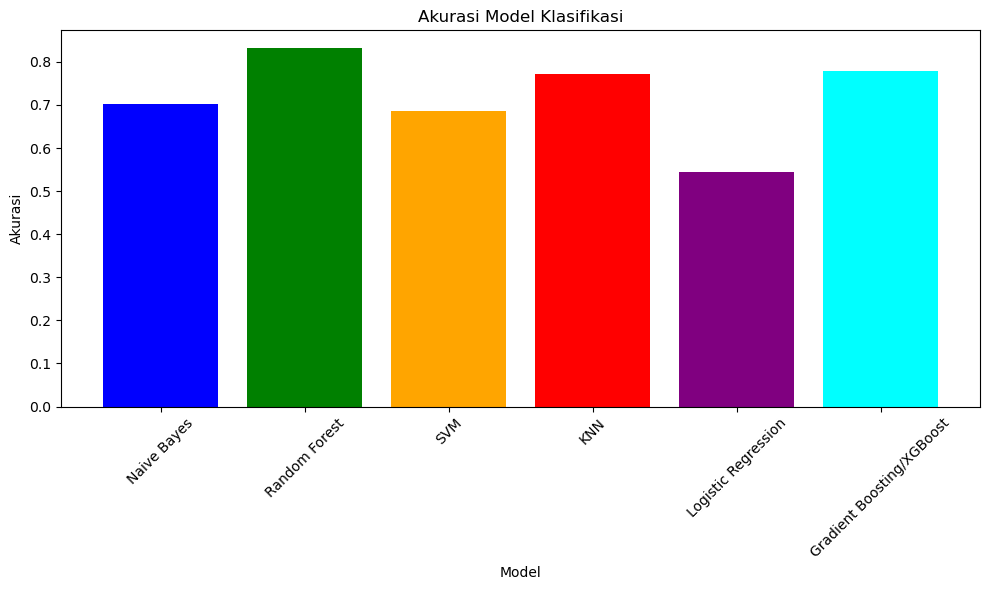

                       Model   Akurasi
0              Random Forest  0.831612
1  Gradient Boosting/XGBoost  0.778396
2                        KNN  0.771247
3                Naive Bayes  0.702145
4                        SVM  0.686259
5        Logistic Regression  0.544083
Model terbaik: Random Forest dengan akurasi 0.83


In [44]:
# Make plotting for every model
plt.figure(figsize=(10, 6))
plt.bar(model, acc, color=['blue', 'green', 'orange', 'red', 'purple', 'cyan'])
plt.xlabel('Model')
plt.ylabel('Akurasi')
plt.title('Akurasi Model Klasifikasi')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    'Model': model,
    'Akurasi': acc
})

results_df = results_df.sort_values(by='Akurasi', ascending=False).reset_index(drop=True)
print(results_df)

best_model_index = np.argmax(acc)
best_model = model[best_model_index]
print(f"Model terbaik: {best_model} dengan akurasi {acc[best_model_index]:.2f}")